[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SwissChardLeaf/icrn/blob/main/docs/tutorials/getting_started.ipynb)
[![View on GitHub](https://img.shields.io/badge/source-GitHub-blue?logo=github)](https://github.com/SwissChardLeaf/icrn/blob/main/docs/tutorials/getting_started.ipynb)

Getting Started with icrn
=========================

icrn is a python library for the tensor-based and differentiable simulation of [indexed chemical reaction networks](https://doi.org/10.4230/LIPIcs.DNA.31.4).

# Installing icrn

icrn is registered on PyPi and can be installed using pip.

In [ ]:
!uv pip install icrn

Using Python 3.12.11 environment at: /usr
Audited 1 package in 222ms


Confirm that the installation was successful.

In [ ]:
!uv pip show icrn

Using Python 3.12.11 environment at: /usr
Name: icrn
Version: 0.2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: jax, numpy
Required-by:


# Simulating Your First ICRN

An indexed chemical reaction network (ICRN) is composed of chemical species and rate constants related by index symbols. An ICRN is built programmatically from these analogous building blocks. Notice that the index symbols have an associated parameter that specifies the index set. Currently, the index symbols have index sets {0...n-1}, where n can be specified as an input to an index symbol constructor.

In [1]:
from icrn import many_index_symbols, many_rate_constants, many_species

In [2]:
A = many_species("A")
alpha = many_rate_constants("alpha")
i, j = many_index_symbols("i, j", 5)

The parameters to a mass action reaction constructor are reactant, product, and rate constant information, respectively. A reaction network is simply a list of reactions.

In [3]:
from icrn import MassActionReaction

In [4]:
rxns = [
    MassActionReaction(
        0,  # no reactant
        A[i],  # product is the species A indexed by i
        alpha[i],  # rate constant alpha, also indexed by i
    ),
    MassActionReaction(
        A[j],  # reactant A indexed by j
        0,  # no product
        1.0,  # constant rate of 1
    ),
]

Before we begin simulating, we need to specify the initial concentrations of the species and the values of the rate constants. These are plain Python dictionaries mapping each symbol to a JAX array.

The shape of each array is implied by the association of index symbols. For example, `A[i]` implies that the shape of `A` is `(5,)` because the index set associated with `i` is {0,...,4}.

In [5]:
import jax.numpy as jnp

conc_vals = {A: jnp.ones(5)}
rate_constant_vals = {alpha: jnp.arange(1.0, 6.0)}

print(conc_vals)
print(rate_constant_vals)

{A: Array([1., 1., 1., 1., 1.], dtype=float32)}
{alpha: Array([1., 2., 3., 4., 5.], dtype=float32)}


The network is simulated with `solve_well_mixed`. It takes the list of reactions, the initial concentrations, the rate constant values, the times at which to sample the trajectory, and the integrator step size `dt`.

Here we simulate the system over 10 units of time, sampling at 1001 evenly spaced time points.

In [6]:
from icrn import solve_well_mixed

times = jnp.linspace(0.0, 10.0, 1001)
dt = 1e-4

concs_hist = solve_well_mixed(rxns, conc_vals, rate_constant_vals, times, dt)

As anticipated, the steady state concentration of A is dictated by their production rates, alpha, essentially [1, 2, 3, 4, 5].

In [7]:
final_concs = {species: hist[-1] for species, hist in concs_hist.items()}
final_concs

{A: Array([1.       , 1.9994041, 2.9988081, 3.9988081, 4.9976163], dtype=float32)}

The result is a dictionary mapping each species to its trajectory. The leading dimension is the time axis: it contains the initial state plus one entry for every sampled time point.

In [8]:
concs_hist[A].shape

(1001, 5)

The history can be plotted using matplotlib. If you're not familiar already with matplotlib, there are lots of tutorials online, but it's beyond the scope of this tutorial.

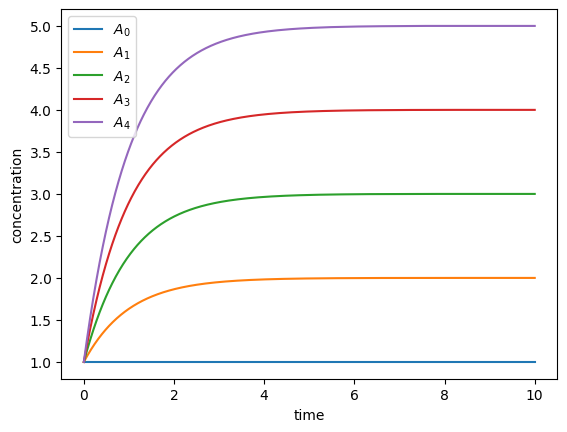

In [9]:
import matplotlib.pyplot as plt

for idx in range(5):
    plt.plot(times, concs_hist[A][:, idx], label=f"$A_{idx}$")
plt.legend()
plt.xlabel("time")
plt.ylabel("concentration")
plt.show()

# Further Reading

Now you are ready to work with icrn!

Check out the other tutorials for more information.

*   Reaction Diffusion Systems
*   ICRN Numerics
*   Training ICRNs
*   Profiling Computations
